In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from wordcloud import STOPWORDS

warnings.filterwarnings("ignore")

matplotlib.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

OCULA_MAP = {
    "HS0": "normal",
    "HS1": "offensive",
    "HSN": "hate",
}
CLASS_COLORS = {"hate": "#111111", "offensive": "#888888", "normal": "#CCCCCC"}
OCULA_ORDER  = ["hate", "offensive", "normal"]
PLOT_DIR     = "./plots/indo_hate"
os.makedirs(PLOT_DIR, exist_ok=True)

STOPWORDS.update([
    "the","a","an","is","it","in","on","at","to","of","and","or",
    "but","not","s","t","http","https","co","amp","i","you","he",
    "she","they","we","me","my","your","this","that","are","was",
    "be","for","with","have","from","do","hai","ki","ka","ke","ko",
    "se","bhi","toh","aur","nahi","nhi","kya","jo","ne","koi",
])

print("✓ Imports complete")

✓ Imports complete


In [2]:
df = pd.read_excel("../data/raw/indo_hate.xlsx")
print(f"Loaded: {len(df):,} rows | columns: {list(df.columns)}")

# Drop null comments
before = len(df)
df = df.dropna(subset=["Comment"])
print(f"After dropping null comments: {len(df):,} rows (dropped {before - len(df):,})")

# Strip quotes from Label: "'HS0'" → "HS0"
df["Label"] = df["Label"].astype(str).str.strip("'").str.strip()

# Map to OCULA label
df["ocula_label"] = df["Label"].map(OCULA_MAP)
unmapped = df["ocula_label"].isna().sum()
if unmapped:
    print(f"Warning: {unmapped} rows with unmapped labels: {df[df['ocula_label'].isna()]['Label'].unique()}")
df = df.dropna(subset=["ocula_label"])

print(f"Final rows: {len(df):,}")
print(f"Label value counts:\n{df['Label'].value_counts().to_string()}")

Loaded: 77,926 rows | columns: ['Source.Name', 'Column1', 'Column2', 'Date', 'Likes', 'Comment', '(view source)', 'Post ID', 'Label']
After dropping null comments: 76,566 rows (dropped 1,360)
Final rows: 76,566
Label value counts:
Label
HS0    62834
HS1    11034
HSN     2698


In [3]:
EMOJI_RE = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002700-\U000027BF"
    "\U0001F900-\U0001F9FF"
    "\U00002600-\U000026FF"
    "]+", flags=re.UNICODE
)

df["word_count"]      = df["Comment"].astype(str).str.split().str.len()
df["char_count"]      = df["Comment"].astype(str).str.len()
df["has_devanagari"]  = df["Comment"].astype(str).apply(
    lambda t: bool(re.search(r"[\u0900-\u097F]", t))
)
df["has_emoji"]       = df["Comment"].astype(str).apply(
    lambda t: bool(EMOJI_RE.search(t))
)

# Parse date column safely
df["comment_date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Feature columns added.")
print(df[["Comment","Label","ocula_label","word_count","has_devanagari","has_emoji"]].head(4))

Feature columns added.
                                             Comment Label ocula_label  \
0  Nice buro yes I am Hussain khan is me happy ow...   HS0      normal   
1                 @hussainkhansadab teri maa chodate   HS1   offensive   
2  @hussainkhansadab mohhamad and allah mi maa ki...   HS1   offensive   
3  @hussainkhansadab Teri maka bhosda lose nikalo...   HSN        hate   

   word_count  has_devanagari  has_emoji  
0          24           False      False  
1           4           False      False  
2           8           False      False  
3           8           False      False  


In [4]:
vc = df["ocula_label"].value_counts().reindex(OCULA_ORDER, fill_value=0)
total = len(df)
imbalance = vc.max() / vc.min()

print("OCULA label distribution:")
for lbl in OCULA_ORDER:
    print(f"  {lbl:<12}: {vc[lbl]:>6,}  ({vc[lbl]/total*100:.1f}%)")
print(f"\nImbalance ratio (normal/hate): {imbalance:.1f}x")

OCULA label distribution:
  hate        :  2,698  (3.5%)
  offensive   : 11,034  (14.4%)
  normal      : 62,834  (82.1%)

Imbalance ratio (normal/hate): 23.3x


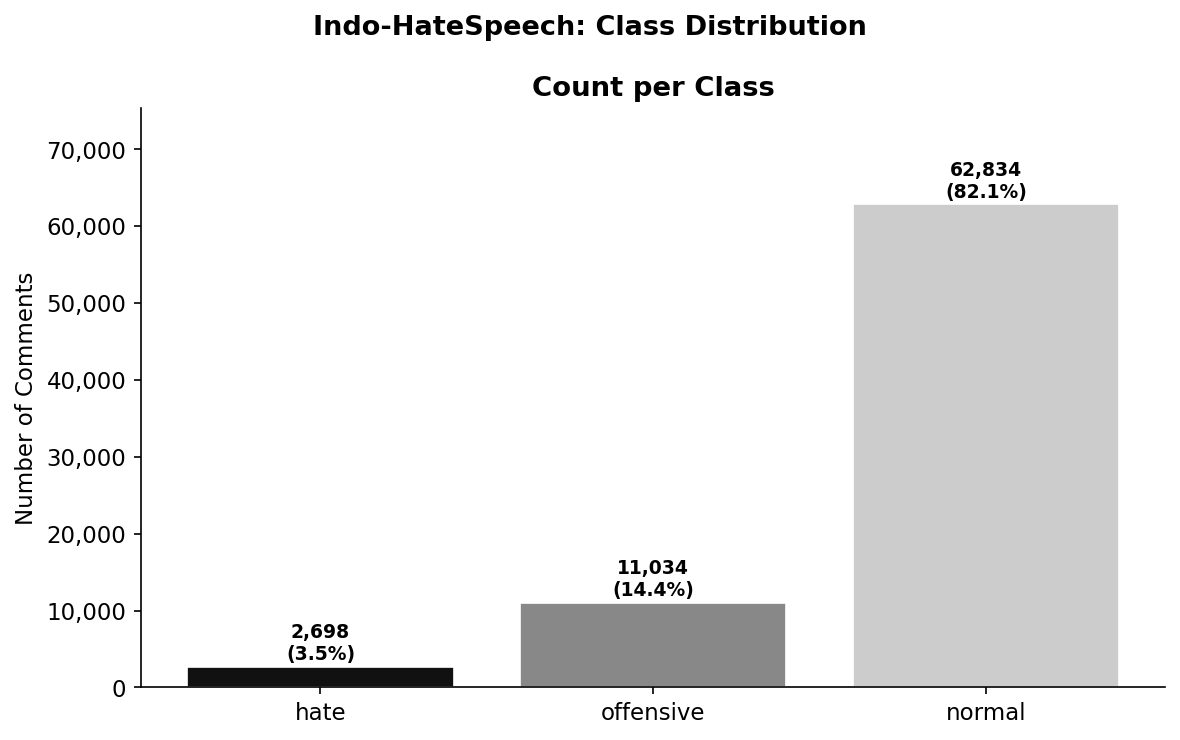

✓ Saved 01_class_distribution.png


In [5]:
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
fig.suptitle("Indo-HateSpeech: Class Distribution",
             fontsize=13, fontweight="bold")

colors = [CLASS_COLORS[l] for l in OCULA_ORDER]

# Bar chart
ax = axes
bars = ax.bar(OCULA_ORDER, vc.values, color=colors, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f"{v:,}\n({v/total*100:.1f}%)",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Count per Class", fontweight="bold")
ax.set_ylabel("Number of Comments")
ax.set_ylim(0, vc.max() * 1.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))


plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/01_class_distribution.png", bbox_inches="tight")
plt.show()
print("✓ Saved 01_class_distribution.png")

In [6]:
print("Word count statistics per OCULA class:")
print(f"{'Class':<12} {'Mean':>7} {'Median':>8} {'95th':>8}")
print("-" * 38)
for lbl in OCULA_ORDER:
    sub = df[df["ocula_label"] == lbl]["word_count"]
    print(f"{lbl:<12} {sub.mean():>7.1f} {sub.median():>8.1f} {sub.quantile(0.95):>8.1f}")

Word count statistics per OCULA class:
Class           Mean   Median     95th
--------------------------------------
hate            12.0      8.0     35.0
offensive        8.4      6.0     22.0
normal           6.6      4.0     19.0


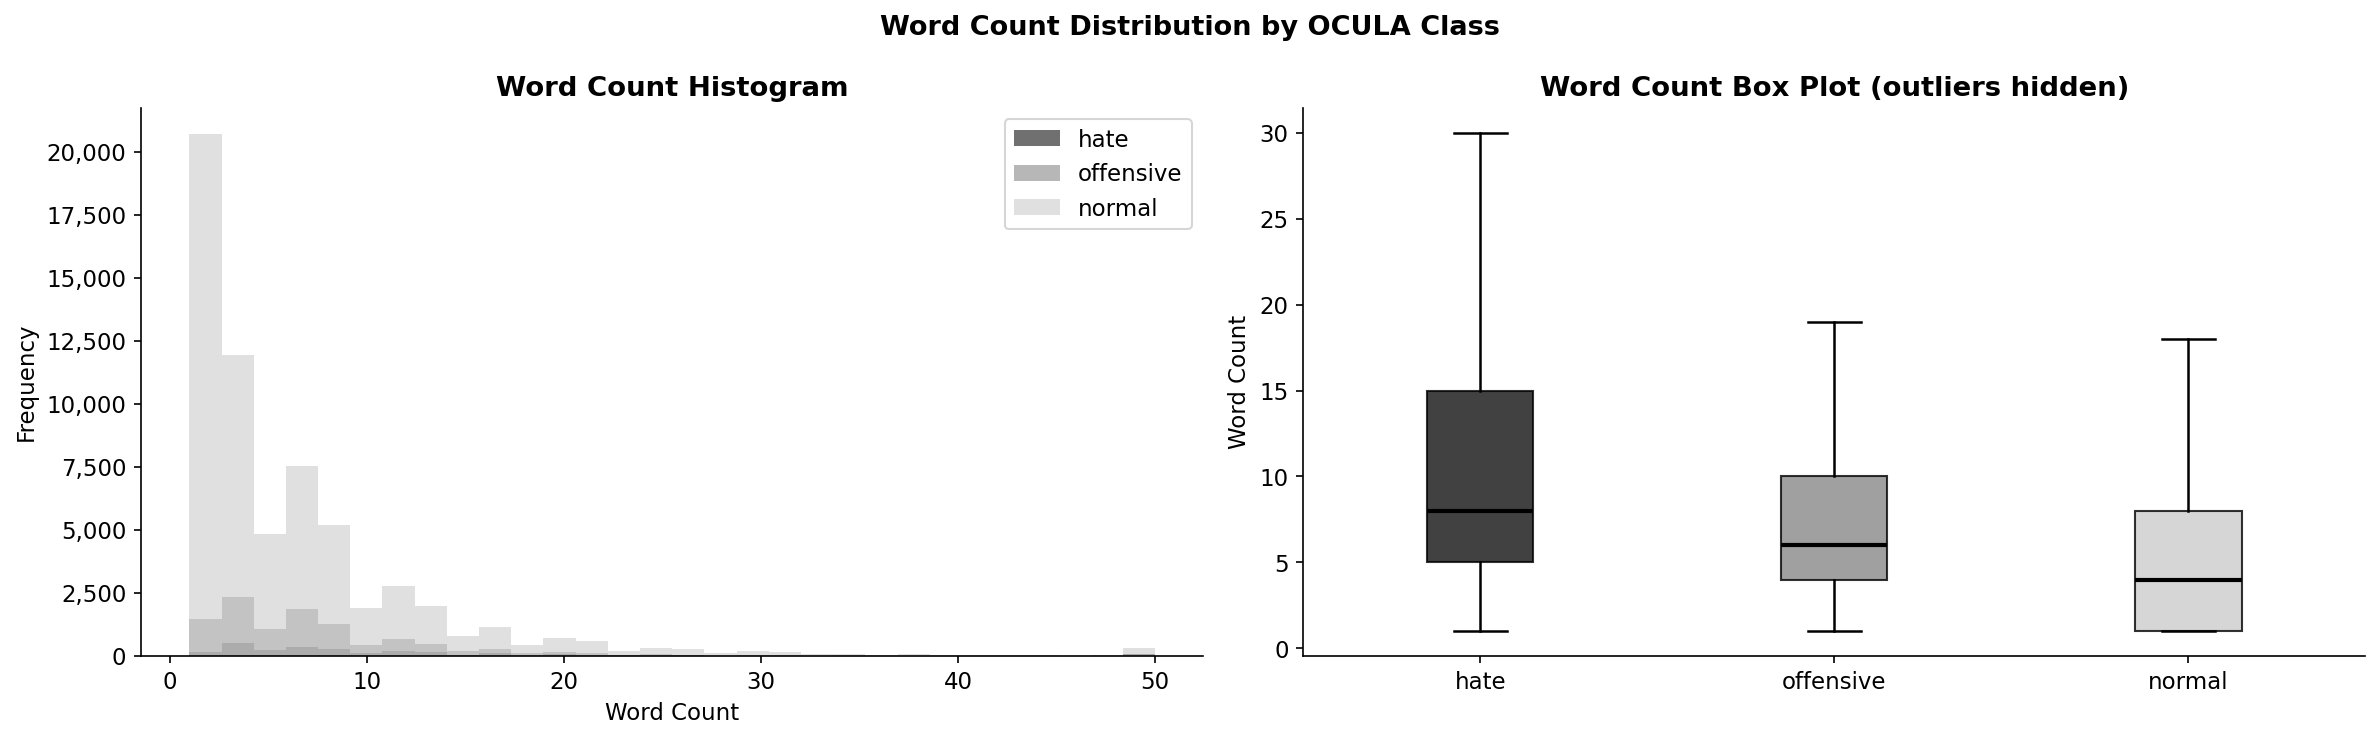

✓ Saved 02_text_length.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Word Count Distribution by OCULA Class", fontsize=13, fontweight="bold")

# Histograms
ax = axes[0]
for lbl in OCULA_ORDER:
    sub = df[df["ocula_label"] == lbl]["word_count"]
    ax.hist(sub.clip(upper=50), bins=30, alpha=0.6,
            color=CLASS_COLORS[lbl], label=lbl, edgecolor="none")
ax.set_title("Word Count Histogram", fontweight="bold")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Box plot
ax = axes[1]
groups      = [df[df["ocula_label"] == l]["word_count"].values for l in OCULA_ORDER]
bp = ax.boxplot(groups, patch_artist=True, notch=False,
                medianprops=dict(color="black", lw=2),
                whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                showfliers=False)
for patch, color in zip(bp["boxes"], [CLASS_COLORS[l] for l in OCULA_ORDER]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels(OCULA_ORDER)
ax.set_title("Word Count Box Plot (outliers hidden)", fontweight="bold")
ax.set_ylabel("Word Count")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/02_text_length.png", bbox_inches="tight")
plt.show()
print("✓ Saved 02_text_length.png")

In [8]:
print("Missing values per column:")
print("-" * 40)
for col in df.columns:
    n_miss = df[col].isna().sum()
    pct    = n_miss / len(df) * 100
    print(f"  {col:<25}: {n_miss:>6,}  ({pct:.1f}%)")

dup_rate  = df["Comment"].duplicated().sum()
short_3   = (df["word_count"] < 3).sum()
empty     = (df["word_count"] == 0).sum()

print(f"\nDuplicate comments      : {dup_rate:>6,}  ({dup_rate/len(df)*100:.1f}%)")
print(f"Very short (<3 words)   : {short_3:>6,}  ({short_3/len(df)*100:.1f}%)")
print(f"Empty / no-text         : {empty:>6,}  ({empty/len(df)*100:.1f}%)")

Missing values per column:
----------------------------------------
  Source.Name              :      0  (0.0%)
  Column1                  :  2,476  (3.2%)
  Column2                  : 74,090  (96.8%)
  Date                     :      0  (0.0%)
  Likes                    : 66,809  (87.3%)
  Comment                  :      0  (0.0%)
  (view source)            :      0  (0.0%)
  Post ID                  :      0  (0.0%)
  Label                    :      0  (0.0%)
  ocula_label              :      0  (0.0%)
  word_count               :      0  (0.0%)
  char_count               :      0  (0.0%)
  has_devanagari           :      0  (0.0%)
  has_emoji                :      0  (0.0%)
  comment_date             :      0  (0.0%)

Duplicate comments      : 18,418  (24.1%)
Very short (<3 words)   : 22,328  (29.2%)
Empty / no-text         :      0  (0.0%)


In [9]:
def split_tokens(texts, stopwords=STOPWORDS):
    """Return (english_tokens, devanagari_tokens) for a list of comment strings."""
    en_tokens, hi_tokens = [], []
    for text in texts:
        for tok in str(text).split():
            tok_clean = re.sub(r"[^\w\u0900-\u097F]", "", tok).lower()
            if len(tok_clean) < 2 or tok_clean in stopwords:
                continue
            if re.search(r"[\u0900-\u097F]", tok_clean):
                hi_tokens.append(tok_clean)
            else:
                en_tokens.append(tok_clean)
    return en_tokens, hi_tokens

top_en_words = {}
top_hi_words = {}
for lbl in OCULA_ORDER:
    texts = df[df["ocula_label"] == lbl]["Comment"]
    en_tok, hi_tok = split_tokens(texts)
    top_en_words[lbl] = Counter(en_tok).most_common(15)
    top_hi_words[lbl] = Counter(hi_tok).most_common(15)

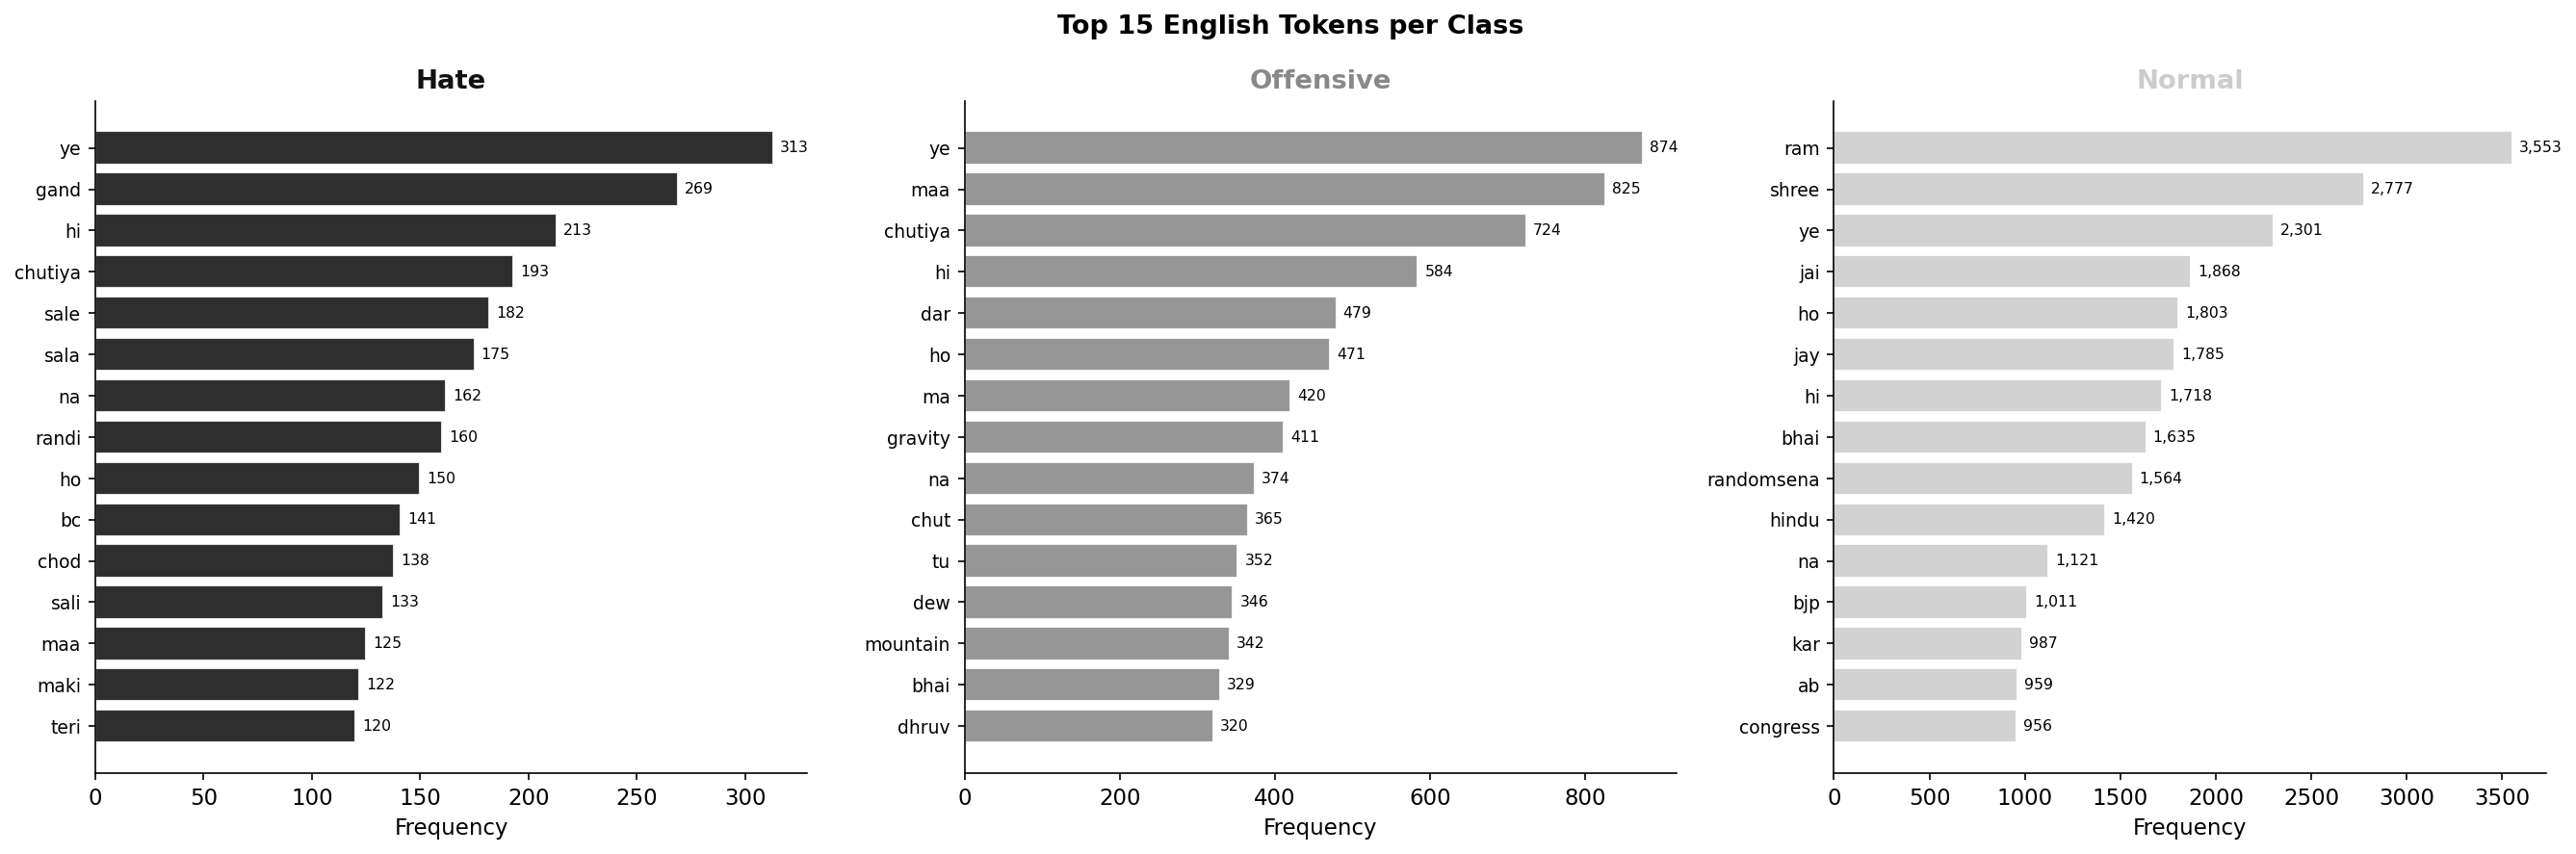

✓ Saved 05_top_unigrams_english_tokens.png


In [10]:
# English tokens — plotted
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Top 15 English Tokens per Class",
             fontsize=13, fontweight="bold")

for ax, lbl in zip(axes, OCULA_ORDER):
    if not top_en_words[lbl]:
        ax.set_title(f"{lbl} (no data)")
        continue
    words, freqs = zip(*top_en_words[lbl])
    y_pos = np.arange(len(words))
    ax.barh(y_pos, freqs, color=CLASS_COLORS[lbl], edgecolor="white", alpha=0.88)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(lbl.capitalize(), fontweight="bold", color=CLASS_COLORS[lbl])
    ax.set_xlabel("Frequency")
    for i, v in enumerate(freqs):
        ax.text(v + max(freqs)*0.01, i, f"{v:,}", va="center", fontsize=7.5)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/05_top_unigrams_english_tokens.png", bbox_inches="tight")
plt.show()
print("✓ Saved 05_top_unigrams_english_tokens.png")

In [11]:
deva_pct = df["has_devanagari"].mean() * 100
dup_pct  = df["Comment"].duplicated().mean() * 100
short_pct= (df["word_count"] < 3).mean() * 100

print("=" * 60)
print("  OCULA — Indo-HateSpeech  |  Data Quality Summary")
print("=" * 60)
print(f"  Raw rows (before cleaning) : {before:>8,}")
print(f"  After dropping null comment: {len(df):>8,}")
print(f"  Dropped                    : {before - len(df):>8,}")
print()
print(f"  Class distribution (OCULA labels):")
for lbl in OCULA_ORDER:
    cnt = vc[lbl]
    print(f"    {lbl:<12}: {cnt:>6,}  ({cnt/total*100:.1f}%)")
print()
print(f"  Imbalance ratio (normal/hate): {imbalance:.1f}x")
print(f"  % with Devanagari script     : {deva_pct:.1f}%")
print(f"  % duplicate comments         : {dup_pct:.1f}%")
print(f"  % very short (<3 words)      : {short_pct:.1f}%")
print("=" * 60)

  OCULA — Indo-HateSpeech  |  Data Quality Summary
  Raw rows (before cleaning) :   77,926
  After dropping null comment:   76,566
  Dropped                    :    1,360

  Class distribution (OCULA labels):
    hate        :  2,698  (3.5%)
    offensive   : 11,034  (14.4%)
    normal      : 62,834  (82.1%)

  Imbalance ratio (normal/hate): 23.3x
  % with Devanagari script     : 11.2%
  % duplicate comments         : 24.1%
  % very short (<3 words)      : 29.2%
